In [1]:
from pathlib import Path

path = Path("pmp.sdf")
print(path.exists())
print(path.stat().st_size)
print(path.read_text(errors="ignore")[:1000])

True
3012
Molecule Name
 OpenBabel04232619403D

 32 31  0  0  0  0  0  0  0  0999 V2000
    1.0315    2.8140   -0.8917 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0535    1.9581   -0.2575 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2442    2.2005   -0.4564 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.3287    0.9225    0.5580 N   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7514    0.1377    1.1546 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3671   -0.8816    0.1756 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6304   -1.7097   -0.3616 O   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7210   -0.8814    0.0046 N   0  0  0  0  0  0  0  0  0  0  0  0
   -3.6182    0.1837    0.4512 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.3220   -1.9510   -0.7839 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.5395    3.5086   -1.5715 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.7600    2.2172   -1.4476 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.5773    3.3882   -0.1354 H   0  0  0  0  0  0  0  0  0  0  0  0
  

In [2]:
from rdkit import Chem

suppl = Chem.SDMolSupplier("pmp.sdf", removeHs=False, sanitize=False)

mols = [m for m in suppl if m is not None]
print("number of readable molecules:", len(mols))

for i, m in enumerate(suppl):
    if m is None:
        print("failed at molecule", i)

number of readable molecules: 1


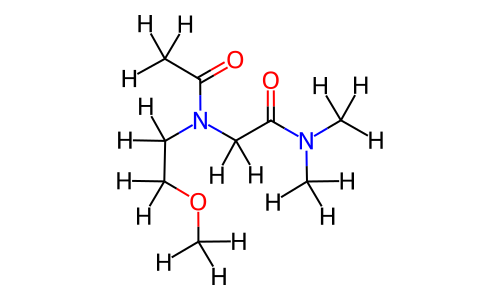

In [3]:
from openff.toolkit import Molecule

mol = Molecule.from_file("pmp.sdf")

# visualize
mol.visualize()

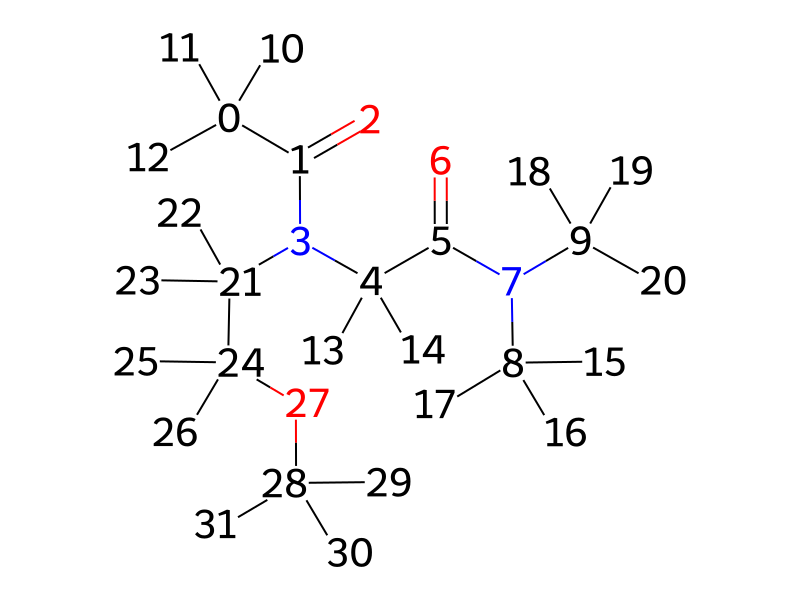

In [4]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

rdmol = Chem.MolFromMolFile("pmp.sdf", removeHs=False)

for atom in rdmol.GetAtoms():
    atom.SetProp("atomLabel", str(atom.GetIdx()))

rdDepictor.Compute2DCoords(rdmol)

drawer = rdMolDraw2D.MolDraw2DCairo(800, 600)
drawer.DrawMolecule(rdmol)
drawer.FinishDrawing()

with open("s00.png", "wb") as f:
    f.write(drawer.GetDrawingText())

display(Image(filename="s00.png"))

In [5]:
import sys
print(sys.executable)

try:
    import openmm
    import openmm.app as app
    import openmm.unit as unit
    print("OpenMM installed")
    print("OpenMM version:", openmm.version.version)
except Exception as e:
    print("OpenMM import failed")
    print(e)

try:
    from openff.toolkit import Molecule, ForceField
    print("OpenFF Toolkit installed")
except Exception as e:
    print("OpenFF import failed")
    print(e)

/home/tuu61186/miniconda3/envs/openff/bin/python
OpenMM installed
OpenMM version: 8.5.1.dev-f7fa0c2
OpenFF Toolkit installed


20 conformers

In [6]:
from openff.toolkit import Molecule, ForceField
import openmm
import openmm.app as app
import openmm.unit as unit

mol = Molecule.from_file("pmp.sdf")

if not mol.conformers:
    mol.generate_conformers(n_conformers=20)

ff = ForceField("openff-2.2.0.offxml")
interchange = ff.create_interchange(mol.to_topology())

system = interchange.to_openmm()
topology = interchange.topology.to_openmm()
positions = interchange.positions.to_openmm()

/home/tuu61186/miniconda3/envs/openff/lib/python3.10/site-packages/openff/amber_ff_ports/amber_ff_ports.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [ ]:
sbatch run_20.sh

In [7]:
import mdtraj as md
import numpy as np

traj_files = [f"traj_{i}.dcd" for i in range(6)]
traj = md.load(traj_files, top="topology.pdb")

phi_atoms = [1, 3, 4, 5]  # phi atom index
psi_atoms = [3, 4, 5, 7]  # psi atom index

angles = md.compute_dihedrals(traj, [phi_atoms, psi_atoms])

phi = np.degrees(angles[:, 0])
psi = np.degrees(angles[:, 1])

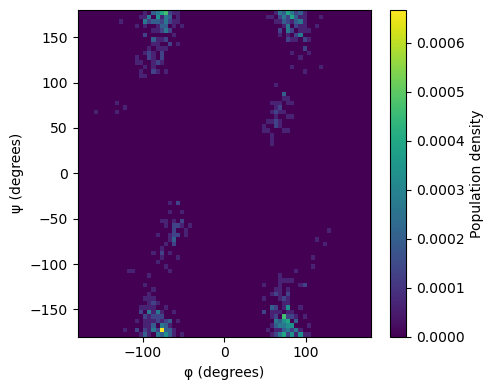

In [8]:
import matplotlib.pyplot as plt

H, xedges, yedges = np.histogram2d(
    phi,
    psi,
    bins=72,
    range=[[-180, 180], [-180, 180]],
    density=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(
    H.T,
    origin="lower",
    extent=[-180, 180, -180, 180],
    aspect="auto",
)

plt.xlabel("φ (degrees)")
plt.ylabel("ψ (degrees)")
plt.colorbar(label="Population density")
plt.tight_layout()
plt.savefig("phi_psi_population_map.png", dpi=300)
plt.show()

DFT calculation with Gaussian 09
- scaning psi dihedrals with 36 fixed phi dihedrals

In [1]:
import pandas as pd

df = pd.read_csv("dft_2d_phi_psi_population.csv")

# 36x36 = 1296
files_to_keep = df["source_file"].drop_duplicates().iloc[:36]
df = df[df["source_file"].isin(files_to_keep)].copy()

# 重新 normalize population
df["boltzmann_weight"] = df["boltzmann_weight"]
df["population"] = df["boltzmann_weight"] / df["boltzmann_weight"].sum()

df.to_csv("dft_2d_phi_psi_population_36x36.csv", index=False)

print(len(df))

1296


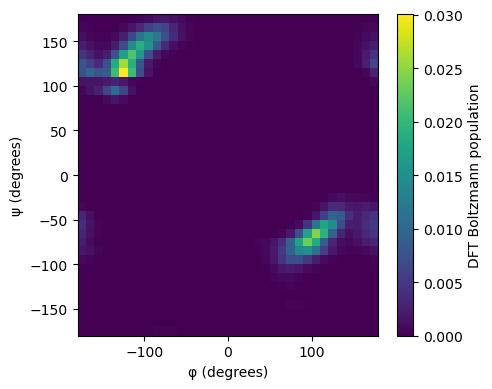

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dft_2d_phi_psi_population_36x36.csv")

plt.figure(figsize=(5, 4))
plt.hist2d(
    df["phi_deg"],
    df["psi_deg"],
    bins=36,
    range=[[-180, 180], [-180, 180]],
    weights=df["population"],
)

plt.xlabel("φ (degrees)")
plt.ylabel("ψ (degrees)")
plt.colorbar(label="DFT Boltzmann population")
plt.tight_layout()
plt.savefig("dft_2d_population_map.png", dpi=300)
plt.show()